In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.metrics import mean_absolute_error, r2_score

In [45]:
!mkdir -p "lab5"
!wget -q -O "lab5/synthetic_bp.csv" "https://github.com/SunLab-Rutgers/chem542_CDS/raw/main/labs/lab5/data/synthetic_gp_data.csv"

In [46]:
# load the csv file
df_all = pd.read_csv("lab5/synthetic_bp.csv")
print(df_all.columns)

Index(['name', 'molweight', 'critical temperature (K)', 'acentric factor',
       'boiling point (K)'],
      dtype='object')


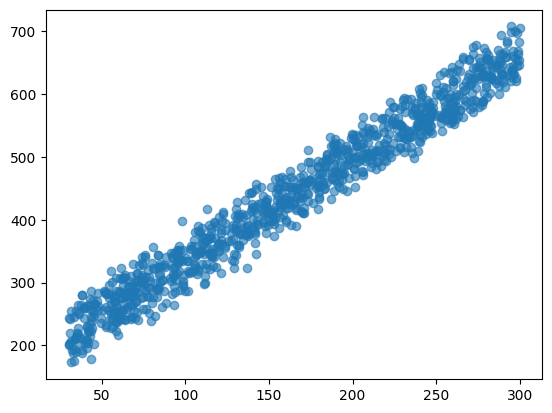

In [47]:
# let's see the relationship between BP and the features
plt.scatter(df_all["molweight"], df_all["boiling point (K)"], alpha=0.6,)

In [48]:
# it's a lot of data, let's reduce the size
df = df_all.sample(n=200, random_state=42)

In [49]:
# Define feature and dependent variables
X = df[["molweight", "critical temperature (K)", "acentric factor"]].values
y = df["boiling point (K)"].values

In [50]:
# Split training and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [51]:
# Rescaling is critical
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [52]:
# Initiate the kernel
# with ranges that it should optimize for
kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(
    length_scale=[1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 20.0)
)

In [53]:
# initiate the Gaussian Process Regression Model
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=0
)

In [54]:
# GPR is learning the kernel coefficients
gp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 20.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 20.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=0.01, kernel=1**2 * RBF(length_scale=[1, 1, 1]),
                         n_restarts_optimizer=5, normalize_y=True,
                         random_state=0)

In [56]:
# Predict
y_pred, y_std = gp.predict(X_test, return_std=True)
print(y_pred)
print(y_std)


[262.86499081 260.63800375 466.01178888 573.4673578  509.79045384
 441.47379621 304.0103234  198.75628785 533.04686038 438.31513377
 522.66412569 464.964602   570.99706094 599.44955012 393.08179429
 365.79745783 454.28139037 481.42350495 636.54741213 623.75853663
 621.85866417 628.24401634 401.0103461  294.0492012  617.18270342
 251.30327382 434.65661331 428.67736257 643.80289022 506.77657023
 220.86684628 551.93479539 282.309151   526.2631226  347.27516088
 589.86482163 544.12795532 552.40027354 366.7927689  219.48914187]
[2.4960148  2.24426181 1.85380829 1.86722724 3.41363353 2.53424584
 3.28365539 4.16366313 2.42221017 3.01427068 1.79519121 2.52305766
 1.76133895 2.00003477 1.90961849 2.10240442 1.95227683 1.81843396
 2.51395631 2.19593111 2.53267864 3.88706013 2.59411516 1.82384224
 3.91473106 3.19951302 1.72197748 1.71671187 3.2972948  1.86202288
 3.44910635 1.69536235 2.72938293 1.82216803 3.93010404 1.70837352
 2.02124888 3.3097339  1.88751475 3.33690946]


In [57]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))
print("Learned kernel:", gp.kernel_)

MAE: 7.873202673461648
R^2: 0.9946608433982759
Learned kernel: 2.79**2 * RBF(length_scale=[20, 6.1, 20])


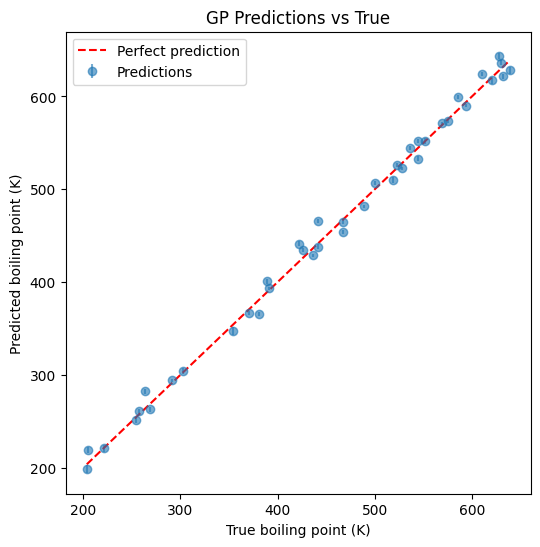

In [58]:
# visualize
plt.figure(figsize=(6,6))
plt.errorbar(
    y_test, y_pred, yerr=y_std, fmt='o', alpha=0.6, label='Predictions'
)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel("True boiling point (K)")
plt.ylabel("Predicted boiling point (K)")
plt.title("GP Predictions vs True")
plt.legend()
plt.show()
